# Laboratorio 2 - AlpesHearth

## Integrantes

- Isabella Naranjo
- David Caro

## Conjunto de datos resultante del laboratorio 1

El conjunto de datos del laboratorio 1 paso por un proceso de exploración, preparación y limpieza. Concluimos que el mejor modelo fue aquel en el cual eliminamos los registros duplicados y eliminamos los registros que tenian nulo en nuestra variable objetivo. Para el manejo de IDs duplicados, eliminamos aquellos registros que tenian el valor de **CVD Risk Score** negativo y promediamos la variable objetivo si exisitan dos IDs iguales con CVD Risk Score positivo diferente. Finalmente eliminamos todos los registros que tenian valores clinicamente imposibles y outliers, no obstante, aunque obtuvimos los mejores valores de $R^2$ Y $RMSE$ en comparación con los otros 2 modelos que realizamos, también obtuvimos que las metricas de TEST eran mejores que las de TRAIN, por tanto, en esta iteración decidimos no eliminar los outliers, pues el hecho de que estamos trabajando con un data set pequeño, y eliminamos una gran cantidad de registros, podría estar afectando la capacidad predictiva del modelo (underfitting).

In [8]:
import pandas as pd 

#Eliminamos registros duplicados y con variable objetivo nula 

df = pd.read_csv("./data/Datos Lab 1.csv")
df_model1 = df.copy()
df_model1 = df_model1.dropna(subset=["CVD Risk Score"])
before = len(df_model1)
df_model1 = df_model1.drop_duplicates(keep="first") #mantenemos solo la primera ocurrencia
after = len(df_model1)
print(f"Duplicados idénticos eliminados: {before - after}")

#Eliminamos registros con CVD Risk Score negativo y dejamos la primera ocurrencia del los IDs duplicados, junto con el valor promediado.

print("Antes:", df_model1["Patient ID"].duplicated().sum(), "IDs duplicados")
ids_duplicados = df_model1[df_model1["Patient ID"].duplicated(keep=False)]
df_model1 = df_model1[df_model1["CVD Risk Score"] >= 0]
cols_sin_target = df_model1.columns.tolist()
cols_sin_target.remove("CVD Risk Score")
cols_sin_target.remove("Patient ID")
df_base = df_model1.drop_duplicates(subset=["Patient ID"], keep="first")[["Patient ID"] + cols_sin_target]
df_score_prom = df_model1.groupby("Patient ID")["CVD Risk Score"].mean().reset_index()
df_model1 = df_base.merge(df_score_prom, on="Patient ID", how="left")
print("Después:", df_model1["Patient ID"].duplicated().sum(), "IDs duplicados")
print(df_model1.shape)

#Eliminamos valores clinicamente imposibles 

df_model1 = df_model1[df_model1["Age"] >= 18]
df_model1 = df_model1[df_model1["Weight (kg)"] >= 30]
df_model1 = df_model1[df_model1["BMI"] >= 10]
df_model1 = df_model1[df_model1["Estimated LDL (mg/dL)"] >= 0]

print("Dimensiones después de eliminar valores imposibles:")
print(df_model1.shape)

numeric_cols = df_model1.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = [c for c in numeric_cols if c != "CVD Risk Score"]
categoric_cols = df_model1.select_dtypes(include=['object']).columns.tolist()
print(f"\nColumnas Numericas ({len(numeric_cols)}): ")
print(numeric_cols)
print(f"\nColumnas Categoricas ({len(categoric_cols)}): ")
print(categoric_cols)

"""
def quitar_outliers(df, col):
    Q1 = df[col].quantile(0.25)   
    Q3 = df[col].quantile(0.75)   
    IQR = Q3 - Q1                 
    
    lower = Q1 - 1 * IQR        
    upper = Q3 + 1 * IQR        
    
    df_filtrado = df[(df[col] >= lower) & (df[col] <= upper)]
    
    print(f"{col}: antes={len(df)}, después={len(df_filtrado)}")
    return df_filtrado
for col in numeric_cols:
    df_model1 = quitar_outliers(df_model1, col)
"""

print("\nDimensiones finales del cojunto de datos: ")
print(df_model1.shape)


Duplicados idénticos eliminados: 150
Antes: 111 IDs duplicados
Después: 0 IDs duplicados
(1344, 24)
Dimensiones después de eliminar valores imposibles:
(1119, 24)

Columnas Numericas (13): 
['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']

Columnas Categoricas (10): 
['Patient ID', 'Date of Service', 'Sex', 'Blood Pressure (mmHg)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category', 'CVD Risk Level']

Dimensiones finales del cojunto de datos: 
(1119, 24)


## 1. Construcción de un modelo de regresión polinomial

Para la construcción del modelo de regresión polinomial, se implementó un pipeline que integra todas las etapas de preprocesamiento y modelado en un solo objeto. Se tomó la decisión de utilizar un `FunctionTransformer` (dropper) dentro del pipeline para eliminar las columnas redundantes o no relevantes (Patient ID, Blood Pressure (mmHg), Height (cm), CVD Risk Level y Date of Service), lo cual garantiza que este paso de limpieza se aplique automáticamente tanto en entrenamiento como en predicción, reduciendo el riesgo de errores y mejorando la reproducibilidad. Para las variables numéricas, se aplicó imputación con la media, escalamiento con StandardScaler y generación de características polinomiales. Para las variables categóricas, se imputaron valores faltantes con la moda y se aplicó codificación OneHot. La búsqueda de hiperparámetros se realizó mediante GridSearchCV, explorando grados polinomiales de 1 a 4, utilizando KFold con 5 particiones, `shuffle=True` y `random_state=42`, lo cual asegura que los datos se mezclen aleatoriamente antes de dividirse, generando folds más representativos y resultados reproducibles. El mejor modelo resultante fue el de grado 1, lo que sugiere que aumentar la complejidad polinomial no mejora el desempeño en este dataset.

In [9]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import FunctionTransformer, Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, validation_curve

#PARTICION: sacar train y test para XY

target = "CVD Risk Score"
X = df_model1.drop(columns=[target])
y = df_model1[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Separacion de variables numericas y categoricas

numeric_features = ["Age",
                    "Weight (kg)","Height (m)",
                    "BMI",
                    "Abdominal Circumference (cm)",
                    "Total Cholesterol (mg/dL)",
                    "HDL (mg/dL)",
                    "Fasting Blood Sugar (mg/dL)",
                    "Waist-to-Height Ratio",
                    "Systolic BP",
                    "Diastolic BP",
                    "Estimated LDL (mg/dL)"
]

categorical_features = ["Sex","Smoking Status","Diabetes Status","Physical Activity Level",
                        "Family History of CVD","Blood Pressure Category"]

print("Numéricas:", list(numeric_features))
print("Categóricas:", list(categorical_features))

# Definir un dropper para eliminar columnas no deseadas 
columns_to_drop = [
    'Patient ID',
    'Blood Pressure (mmHg)',
    'Height (cm)',
    'CVD Risk Level',
    'Date of Service'
]

def drop_columns(df):
    return df.drop(columns=columns_to_drop, errors="ignore")

dropper = FunctionTransformer(drop_columns)

# PIPELINE: variables numericas
numeric_transforme_polinomial = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")), # imputa los valores faltantes con la media de cada columna
    ("scaler", StandardScaler()), # escala todas las variables numericas a la misma escala
    ("polynomial", PolynomialFeatures(degree=2)) # genera nuevas variables a partir de las originales usando grado 2
])

# PIPELINE: variables categoricas

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), # imputa los valores faltantes con la moda de cada columna
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")) # codifica las variables categoricas usando one-hot 
])

# COLUMN TRANSFORMER: hace que cada variable (numerica o categorica) pase por su pipeline correspondiente
preprocessor_polinomial = ColumnTransformer([
    ("num", numeric_transforme_polinomial, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# PIPELINE FINAL: preprocesamiento + modelo
pipeline_regresion_polinomial = Pipeline([
    ("dropper", dropper), # type: ignore
    ("preprocesamiento", preprocessor_polinomial),
    ("modelo", LinearRegression())
])

#BUSQUEDA DE HIPERPARAMETROS CON GRIDSEARCHV
param_grid = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3, 4]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42) #shuffle mezcla los datos, no lo hace en orden

grid = GridSearchCV(
    pipeline_regresion_polinomial,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error", #usar rmse negativo, minizando error
    n_jobs=-1
)

grid.fit(X_train, y_train) 

print("\nMejor configuración:", grid.best_params_)
mejor_modelo = grid.best_estimator_

#METRICAS TRAIN
y_train_pred = mejor_modelo.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("\nMétricas sobre TRAIN:")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train MAE: {mae_train:.4f}")
print(f"Train R²: {r2_train:.4f}")

#METRICAS TEST
y_test_pred = mejor_modelo.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\nMétricas sobre TEST:")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R²: {r2_test:.4f}")

Numéricas: ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']
Categóricas: ['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']

Mejor configuración: {'preprocesamiento__num__polynomial__degree': 1}

Métricas sobre TRAIN:
Train RMSE: 10.7353
Train MAE: 3.5917
Train R²: 0.0645

Métricas sobre TEST:
Test RMSE: 10.6414
Test MAE: 3.4980
Test R²: 0.0529


## 2. Generación de curvas de validación.

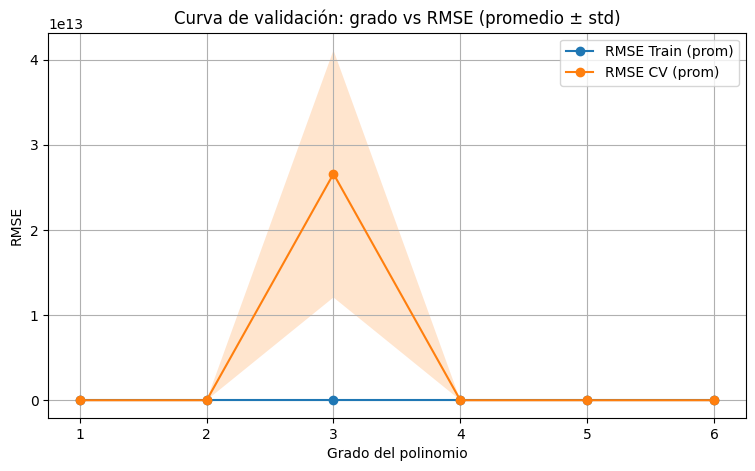


Resultados por grado:
--------------------------------------------------
Grado 1: Train RMSE = 10.6596 (±0.8354), Valid RMSE = 10.4282 (±3.8830)
Grado 2: Train RMSE = 9.7045 (±0.7755), Valid RMSE = 11.6101 (±3.1489)
Grado 3: Train RMSE = 6.4511 (±0.5687), Valid RMSE = 26598424265270.5352 (±14520982350166.3184)
Grado 4: Train RMSE = 0.0000 (±0.0000), Valid RMSE = 59.0084 (±11.2381)
Grado 5: Train RMSE = 0.0000 (±0.0000), Valid RMSE = 42.4995 (±10.9377)
Grado 6: Train RMSE = 0.0000 (±0.0000), Valid RMSE = 69.2265 (±17.6334)


In [10]:
import matplotlib.pyplot as plt

rango = np.arange(1, 7) #mas amplio que el original
cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_scores, val_scores = validation_curve(
    estimator=pipeline_regresion_polinomial,
    X=X_train,
    y=y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=rango,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse = -train_scores
val_rmse = -val_scores

train_mean = train_rmse.mean(axis=1)
train_std  = train_rmse.std(axis=1)

val_mean = val_rmse.mean(axis=1)
val_std  = val_rmse.std(axis=1)


plt.figure(figsize=(9, 5))
plt.plot(rango, train_mean, marker="o", label="RMSE Train (prom)")
plt.fill_between(rango, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(rango, val_mean, marker="o", label="RMSE CV (prom)")
plt.fill_between(rango, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
plt.title("Curva de validación: grado vs RMSE (promedio ± std)")
plt.legend()
plt.grid(True)
plt.show()

print("\nResultados por grado:")
print("-" * 50)
for i, d in enumerate(rango):
    print(f"Grado {d}: Train RMSE = {train_mean[i]:.4f} (±{train_std[i]:.4f}), Valid RMSE = {val_mean[i]:.4f} (±{val_std[i]:.4f})")

## 3. Construcción de modelos de regresión lineal regularizados

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso


#PARTICION: sacar train y test para XY

target = "CVD Risk Score"
X = df_model1.drop(columns=[target])
y = df_model1[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Separacion de variables numericas y categoricas

numeric_features = ["Age",
                    "Weight (kg)","Height (m)",
                    "BMI",
                    "Abdominal Circumference (cm)",
                    "Total Cholesterol (mg/dL)",
                    "HDL (mg/dL)",
                    "Fasting Blood Sugar (mg/dL)",
                    "Waist-to-Height Ratio",
                    "Systolic BP",
                    "Diastolic BP",
                    "Estimated LDL (mg/dL)"
]

categorical_features = ["Sex","Smoking Status","Diabetes Status","Physical Activity Level",
                        "Family History of CVD","Blood Pressure Category"]

print("Numéricas:", list(numeric_features))
print("Categóricas:", list(categorical_features))

# Definir un dropper para eliminar columnas no deseadas 
columns_to_drop = [
    'Patient ID',
    'Blood Pressure (mmHg)',
    'Height (cm)',
    'CVD Risk Level',
    'Date of Service'
]

def drop_columns(df):
    return df.drop(columns=columns_to_drop, errors="ignore")

dropper = FunctionTransformer(drop_columns)

#vamos a manejar el mismo preprocesamiento para los dos modelos

#PIPELINE variables numericas para modelos lineales 
numeric_transforme_lineal = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", "passthrough"),           
    ("polynomial", PolynomialFeatures(degree=1, include_bias=False))
])

#PIPELINE variables categoricas para modelos lineales
preprocessor_lineal = ColumnTransformer([
    ("num", numeric_transforme_lineal, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# MODELO BASE 
baseline = Pipeline([
    ("dropper", dropper),
    ("preprocesamiento", preprocessor_lineal),
    ("modelo", LinearRegression())
])

# BUSQUEDA HIPERPARAMETROS MODELO BASE
param_grid_base = {
    "preprocesamiento__num__scaler": ["passthrough", StandardScaler(), MinMaxScaler()]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_base = GridSearchCV(
    baseline, param_grid_base, cv=cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)
grid_base.fit(X_train, y_train)
best_base = grid_base.best_estimator_
print("BASE best:", grid_base.best_params_, "RMSE_CV:", -grid_base.best_score_)

# RIDGE
ridge = Pipeline([
    ("dropper", dropper),
    ("preprocesamiento", preprocessor_lineal),
    ("modelo", Ridge())
])

# BUSQUEDA HIPERPARAMETROS RIDGE
param_grid_ridge = {
    "preprocesamiento__num__scaler": ["passthrough", StandardScaler(), MinMaxScaler()],
    "modelo__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    ridge, param_grid_ridge, cv=cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_
print("RIDGE best:", grid_ridge.best_params_, "RMSE_CV:", -grid_ridge.best_score_)

# LASSO

lasso = Pipeline([
    ("dropper", dropper),
    ("preprocesamiento", preprocessor_lineal),
    ("modelo", Lasso(max_iter=20000))
])

# BUSQUEDA HIPERPARAMETROS LASSO
param_grid_lasso = {
    "preprocesamiento__num__scaler": ["passthrough", StandardScaler(), MinMaxScaler()],
    "modelo__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

grid_lasso = GridSearchCV(
    lasso, param_grid_lasso, cv=cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_
print("LASSO best:", grid_lasso.best_params_, "RMSE_CV:", -grid_lasso.best_score_)


# EVALUCAION EN TEST
def eval_model(name, model):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"{name} -> RMSE:{rmse:.4f}  MAE:{mae:.4f}  R2:{r2:.4f}")

eval_model("BASE", best_base)
eval_model("RIDGE", best_ridge)
eval_model("LASSO", best_lasso)


# MAGNITUD DE COEFICIENTES RIDGE
coef_base  = best_base.named_steps["modelo"].coef_
coef_ridge = best_ridge.named_steps["modelo"].coef_

print("||coef|| base :", np.linalg.norm(coef_base))
print("||coef|| ridge:", np.linalg.norm(coef_ridge))

# COEFICIENTES EN CERO LASSO
coef_lasso = best_lasso.named_steps["modelo"].coef_
print("Ceros en Lasso:", np.sum(np.isclose(coef_lasso, 0.0)))

## 4. Construcción de un modelo de regresión polinomial regularizado

Para la construcción del modelo de regresión polinomial regularizado, se implementó un pipeline que combina la generación de características polinomiales con regularización Ridge. Se utilizó un `FunctionTransformer` (dropper) para eliminar columnas redundantes dentro del pipeline, garantizando reproducibilidad en predicciones futuras. La búsqueda de hiperparámetros se realizó mediante GridSearchCV con KFold de 5 particiones (`shuffle=True`, `random_state=42`), explorando grados polinomiales de 1 a 4, estrategias de escalamiento (StandardScaler y MinMaxScaler) y valores de regularización alpha (0.01, 0.1, 1, 10, 100). La mejor configuración encontrada fue: grado polinomial 2, MinMaxScaler y alpha=100. El modelo obtuvo un RMSE de 10.2076 (±4.0122) en validación cruzada, con métricas similares en train ($RMSE=10.80$, $R^2=0.0528$) y test ($RMSE=10.65$, $R^2=0.0510$).

Respecto al control del sobreajuste, los resultados sugieren que la regularización Ridge sí permite controlar el sobreajuste al incrementar la complejidad del modelo. El hecho de que el mejor alpha sea 100, el valor más alto explorado, indica que se requiere una penalización fuerte para evitar que el modelo polinomial de grado 2 sobreajuste los datos. Además, la similitud entre las métricas de train y test (diferencia de solo 0.15 en $RMSE$) confirma que la regularización está cumpliendo su función de mejorar la generalización. Sin embargo, el $R^2$ bajo indica que, aunque el modelo generaliza bien, su capacidad predictiva sigue siendo limitada.

In [15]:
from sklearn.linear_model import Lasso, Ridge

# Realizo la partición Train/Test

target = 'CVD Risk Score'
X = df_model1.drop(columns=[target])
y = df_model1[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1
)

numeric_features = ["Age",
                    "Weight (kg)","Height (m)",
                    "BMI",
                    "Abdominal Circumference (cm)",
                    "Total Cholesterol (mg/dL)",
                    "HDL (mg/dL)",
                    "Fasting Blood Sugar (mg/dL)",
                    "Waist-to-Height Ratio",
                    "Systolic BP",
                    "Diastolic BP",
                    "Estimated LDL (mg/dL)"
]

categorical_features = ["Sex","Smoking Status","Diabetes Status","Physical Activity Level",
                        "Family History of CVD","Blood Pressure Category"]

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

# Creo dropper para eliminar las columnas en el pipeline

columns_to_drop = [
    'Patient ID',
    'Blood Pressure (mmHg)',
    'Height (cm)',
    'CVD Risk Level',
    'Date of Service'
]

def drop_columns(df):
    return df.drop(columns=columns_to_drop, errors='ignore')

dropper = FunctionTransformer(drop_columns)

# Creo pipeline de las variables númericas

numeric_transformer_poly_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False))])

# Pipeline variables categoricas

categorical_transformer_poly_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

# Creo el column transformer

preprocessor_poly_reg = ColumnTransformer([
    ('num', numeric_transformer_poly_reg, numeric_features),
    ('cat', categorical_transformer_poly_reg, categorical_features)
])

# Pipeline 

pipeline_poly_ridge = Pipeline([
    ('dropper', dropper),
    ('preprocesamiento', preprocessor_poly_reg),
    ('modelo', Ridge())
])

# Ahora realizo la busqueda de hiperparametros

param_grid = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3, 4],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()],
    "modelo__alpha": [0.01, 0.1, 1, 10, 100]
}

# KFold para mezclar los datos 

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_poly_ridge = GridSearchCV(
    pipeline_poly_ridge,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    return_train_score=True
)

grid_poly_ridge.fit(X_train, y_train)

# Resultados
print("="*60)
print("REGRESIÓN POLINOMIAL REGULARIZADA (RIDGE)")
print("="*60)
print(f"\nMejor configuración: {grid_poly_ridge.best_params_}")
print(f"Mejor RMSE en CV: {-grid_poly_ridge.best_score_:.4f}")

# Métricas de validación cruzada
best_idx = grid_poly_ridge.best_index_
cv_results = grid_poly_ridge.cv_results_
print(f"\nMétricas en Validación Cruzada:")
print(f"RMSE: {-cv_results['mean_test_score'][best_idx]:.4f} (±{cv_results['std_test_score'][best_idx]:.4f})")

# MÉTRICAS EN TRAIN
mejor_modelo_poly_ridge = grid_poly_ridge.best_estimator_
y_train_pred = mejor_modelo_poly_ridge.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"\nMétricas sobre TRAIN:")
print(f"RMSE: {rmse_train:.4f}")
print(f"MAE: {mae_train:.4f}")
print(f"R²: {r2_train:.4f}")

# MÉTRICAS EN TEST
y_test_pred = mejor_modelo_poly_ridge.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"\nMétricas sobre TEST:")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"R²: {r2_test:.4f}")


Numéricas: ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']
Categóricas: ['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']
REGRESIÓN POLINOMIAL REGULARIZADA (RIDGE)

Mejor configuración: {'modelo__alpha': 100, 'preprocesamiento__num__polynomial__degree': 2, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE en CV: 10.2076

Métricas en Validación Cruzada:
RMSE: 10.2076 (±4.0122)

Métricas sobre TRAIN:
RMSE: 10.8023
MAE: 3.4823
R²: 0.0528

Métricas sobre TEST:
RMSE: 10.6517
MAE: 3.4130
R²: 0.0510
